# Lets try and work out which is the best base model

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import strictyaml
import os
import torch
from pathlib import Path
from coconut.load_model import resume_model, tie_embeddings
from coconut.utils import Config, clear_memory
from coconut.dataset import (
    CoconutCollator,
    get_cot_latent_dataset,
    get_dataset,
    get_question_only_latent_dataset,
)

In [3]:
from coconut.dataset import (
    CoconutCollator,
    get_cot_latent_dataset,
    get_dataset,
    get_question_only_latent_dataset,
)

In [4]:
import torch
from coconut.eval import evaluate

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype = torch.bfloat16 if device == 'cuda' else torch.float32

ckpts = list(Path('../outputs/qwen3-0.6b_20250510-205601').glob('*'))

# sort by _\d
ckpts = sorted(ckpts, key=lambda x: int(x.stem.split('_')[-1]))
ckpts

[PosixPath('../outputs/qwen3-0.6b_20250510-205601/checkpoint_0'),
 PosixPath('../outputs/qwen3-0.6b_20250510-205601/checkpoint_1'),
 PosixPath('../outputs/qwen3-0.6b_20250510-205601/checkpoint_2'),
 PosixPath('../outputs/qwen3-0.6b_20250510-205601/checkpoint_3'),
 PosixPath('../outputs/qwen3-0.6b_20250510-205601/checkpoint_4'),
 PosixPath('../outputs/qwen3-0.6b_20250510-205601/checkpoint_5'),
 PosixPath('../outputs/qwen3-0.6b_20250510-205601/checkpoint_6'),
 PosixPath('../outputs/qwen3-0.6b_20250510-205601/checkpoint_7'),
 PosixPath('../outputs/qwen3-0.6b_20250510-205601/checkpoint_8'),
 PosixPath('../outputs/qwen3-0.6b_20250510-205601/checkpoint_9'),
 PosixPath('../outputs/qwen3-0.6b_20250510-205601/checkpoint_10'),
 PosixPath('../outputs/qwen3-0.6b_20250510-205601/checkpoint_11'),
 PosixPath('../outputs/qwen3-0.6b_20250510-205601/checkpoint_12'),
 PosixPath('../outputs/qwen3-0.6b_20250510-205601/checkpoint_13'),
 PosixPath('../outputs/qwen3-0.6b_20250510-205601/checkpoint_14'),
 Posi

In [6]:
from tqdm.auto import tqdm

results = []
for i, c in enumerate(tqdm(ckpts)):
    print(f"Checkpoint 2{i+1}/{len(ckpts)}: {c}")
    # if (i%4 != 0)  and (i!=len(ckpts)):
    #     continue
    # load config
    conf = Config(**strictyaml.load((c / 'config.yaml').open().read()).data)
    conf.load_model_path = str(c)
    conf.train_path = '../'+conf.train_path
    conf.val_path = '../'+conf.val_path
    for k in conf.__dict__.keys():
        try:
            conf.__dict__[k] = int(conf.__dict__[k])
        except:
            try:
                conf.__dict__[k] = float(conf.__dict__[k])
            except:
                pass

    model, tokenizer = resume_model(conf)

    epoch = int(c.stem.split('_')[-1])

    max_latent_epoch = int(conf.max_latent_stage) * int(conf.epochs_per_stage)

    if epoch <= int(conf.cot_epochs):
        scheduled_stage = 0
        no_bot_eot = True
    elif epoch < max_latent_epoch:
        scheduled_stage = (epoch - conf.cot_epochs) // conf.epochs_per_stage
        no_bot_eot = False
    else:
        scheduled_stage = conf.max_latent_stage

    print(epoch, scheduled_stage)

    # load dataset
    # tie_embeddings(model, tokenizer)
    latent_id = tokenizer.convert_tokens_to_ids("<|latent|>")
    bot_id = tokenizer.convert_tokens_to_ids("<|start-latent|>")
    eot_id = tokenizer.convert_tokens_to_ids("<|end-latent|>")
    collator = CoconutCollator(tokenizer, latent_id=latent_id, label_pad_token_id=-100)
    max_new_tokens = 64 # for gsm

    max_size = 100000000
    base_dataset_valid = get_dataset(
        conf.val_path,
        tokenizer,
        max_size=max_size // 30 + 3,
        drop_unused=False,
        system_prompt=conf.system_prompt,
    )
    dataset_gen_val = get_question_only_latent_dataset(
        scheduled_stage,
        base_dataset_valid,
        conf,
        bot_id,
        latent_id,
        eot_id,
        no_bot_eot=no_bot_eot,
        # drop_unused=False,
    )
    valid_gen_dataloader = torch.utils.data.DataLoader(
        dataset_gen_val,
        num_workers=6,
        pin_memory=True,
        batch_size=conf.batch_size_training,
        collate_fn=collator,
    )

    r = evaluate(
        valid_gen_dataloader,
        model,
        tokenizer,
        base_dataset_valid,
        max_new_tokens=max_new_tokens,
        name=f"eval_{epoch}_start",
        dtype=dtype,
        device=device,
        quick=False,
    )
    r['epoch'] = epoch
    r['scheduled_stage'] = scheduled_stage
    r['no_bot_eot'] = no_bot_eot
    r['max_latent_epoch'] = max_latent_epoch
    r['max_size'] = max_size
    r['max_new_tokens'] = max_new_tokens
    r['model_path'] = str(c)
    results.append(r)

    model = None
    clear_memory()


2025-05-13 11:39:27.549 | WARNING  | coconut.load_model:resume_model:58 - Loaded model from ../outputs/qwen3-0.6b_20250510-205601/checkpoint_0


0 0


tokenize_sample: ../data/gsm_valid.json (num_proc=32):   0%|          | 0/500 [00:00<?, ? examples/s]

Example row:
question_tokenized <|im_start|>system
Solve this math question with multiple steps like `<<5*0+1*2=?>>` OR silently within `<|start-latent|><|end-latent|>`. Then return the final answer like `### 2
`. Save all comments until after the answer.
<|im_end|>
<|im_start|>user
John cuts his grass to 2 inches.  It grows .5 inches per month.  When it gets to 4 inches he cuts it back down to 2 inches.  It cost $100 to get his grass cut.  How much does he pay per year?<|im_end|>
<|im_start|>assistant
<think>

</think>


steps_tokenized[0] <<4-2=2>>

steps_tokenized[1] <<2/.5=4>>

steps_tokenized[2] <<12/4=3>>

steps_tokenized[3] <<100*3=300>>

answer_tokenized ### 300
<|im_end|>



process_dataset: q_latent_0 (num_proc=32):   0%|          | 0/500 [00:00<?, ? examples/s]

...

tokenize_sample: ../data/gsm_valid.json (num_proc=32):   0%|          | 0/500 [00:00<?, ? examples/s]

Example row:
question_tokenized <|im_start|>system
Solve this math question with multiple steps like `<<5*0+1*2=?>>` OR silently within `<|start-latent|><|end-latent|>`. Then return the final answer like `### 2
`. Save all comments until after the answer.
<|im_end|>
<|im_start|>user
John cuts his grass to 2 inches.  It grows .5 inches per month.  When it gets to 4 inches he cuts it back down to 2 inches.  It cost $100 to get his grass cut.  How much does he pay per year?<|im_end|>
<|im_start|>assistant
<think>

</think>


steps_tokenized[0] <<4-2=2>>

steps_tokenized[1] <<2/.5=4>>

steps_tokenized[2] <<12/4=3>>

steps_tokenized[3] <<100*3=300>>

answer_tokenized ### 300
<|im_end|>



process_dataset: q_latent_3 (num_proc=32):   0%|          | 0/500 [00:00<?, ? examples/s]

Test Accuracy eval_18_start:   0%|          | 0/42 [00:00<?, ?it/s]

2025-05-13 12:09:06.131 | INFO     | coconut.eval:evaluate:41 - Starting evaluation eval_18_start
2025-05-13 12:09:08.715 | INFO     | coconut.eval:evaluate:99 - Q #0: Question: `John cuts his grass to 2 inches.  It grows .5 inches per month.  When it gets to 4 inches he cuts it back down to 2 inches.  It cost $100 to get his grass cut.  How much does he pay per year?`.
Full question: `<|im_start|>system
	Solve this math question with multiple steps like `<<5*0+1*2=?>>` OR silently within `<|start-latent|><|end-latent|>`. Then return the final answer like `### 2
	`. Save all comments until after the answer.
	
	<|im_start|>user
	John cuts his grass to 2 inches.  It grows .5 inches per month.  When it gets to 4 inches he cuts it back down to 2 inches.  It cost $100 to get his grass cut.  How much does he pay per year?
	<|im_start|>assistant
	<think>
	
	</think>
	
	<|start-latent|><|latent|><|latent|><|latent|><|latent|><|latent|><|latent|><|end-latent|>`.
Full llm output: `['###', ' ', '

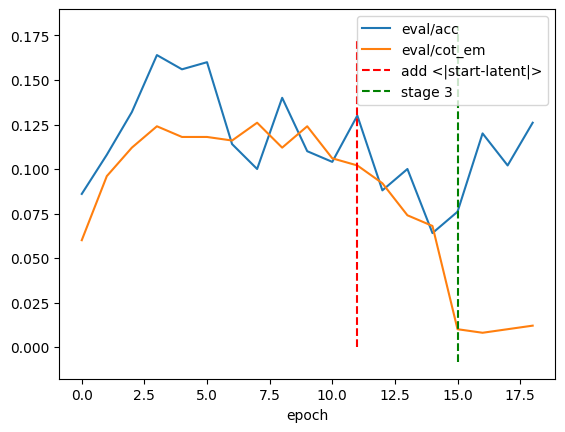

In [7]:
import pandas as pd
from matplotlib import pyplot as plt
df = pd.DataFrame(results).set_index('epoch')
df[['eval/acc', 'eval/cot_em',]].plot()

# hmm instead of events, highlight stages?

i = (~df.no_bot_eot).argmax()
plt.vlines(df.index[i], *plt.ylim(), color='red', linestyle='--', label='add <|start-latent|>')

ms= df['scheduled_stage'].max()
for i in range(1, ms+1):
    dd = df[df.scheduled_stage==i]
    if len(dd) == 0:
        continue
    j = int(dd.index[0])
    plt.vlines(df.loc[j].name, *plt.ylim(), color='green', linestyle='--', label=f'stage {i}')

plt.legend()
# df

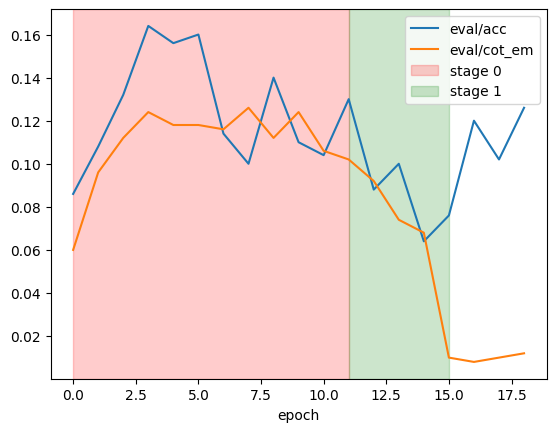

In [8]:
import pandas as pd
from matplotlib import pyplot as plt
df = pd.DataFrame(results).set_index('epoch')
df[['eval/acc', 'eval/cot_em',]].plot()

# hmm instead of events, highlight stages?

stage_epochs = [0]

a=0
b = (~df.no_bot_eot).argmax()
if b>0:
    stage_epochs.append(df.index[b])

ms= df['scheduled_stage'].max()
for i in range(1, ms+1):
    dd = df[df.scheduled_stage==i]
    if len(dd) == 0:
        continue
    j = int(dd.index[0])
    stage_epochs.append(df.loc[j].name)


# now highlight the stages
colors = ['red', 'green', 'blue', 'purple', 'orange']
labels = ['CoT', '<|start-latent|>', '<|latent|>x1', '<|latent|>x2', '<|latent|>x3']
for i in range(len(stage_epochs)-1):
    plt.axvspan(
        stage_epochs[i],
        stage_epochs[i+1],
        color=colors[i % len(colors)],
        label=f'stage {i}',
        alpha=0.2,
    )
plt.legend()

In [9]:
# Try base models with and without prompt